In [13]:
import sys
import os
# Add the scripts folder to the path
sys.path.append(os.path.abspath("scripts"))

# Import functions
from data_processing import convert_all_nc4_to_csv, load_combined_dataframe, get_season
from spatial_analysis import (filter_by_africa_bounds, get_africa_shape, 
                              create_geodataframe_from_grid, clip_to_africa,
                              create_geodataframe_polygons, extract_land_cover)
from visualization import (plot_monthly_grid, plot_annual_mean_map, 
                           plot_seasonal_maps, plot_monthly_timeseries, 
                           plot_co2_by_land_cover)

In [2]:
# 1. Processing
convert_all_nc4_to_csv("data", "data_csv")

Processed 362 files.


In [3]:
df_all = load_combined_dataframe("data_csv")

In [4]:
# 2. DATA LOADING
df_africa = filter_by_africa_bounds(df_all)
df_africa["season"] = df_africa["month"].apply(get_season)  
africa_shape = get_africa_shape("data_shapefile/ne_110m_admin_0_countries.shp")

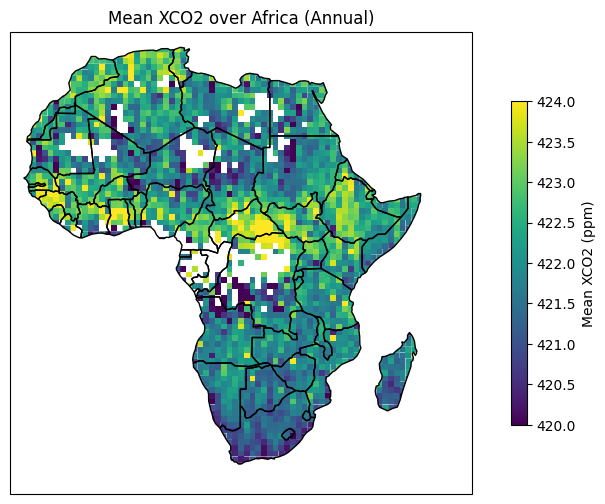

In [5]:
# 3. Annual Plot
gdf_poly = create_geodataframe_polygons(df_africa)
gdf_annual = clip_to_africa(gdf_poly, africa_shape)
plot_annual_mean_map(gdf_annual, africa_shape)

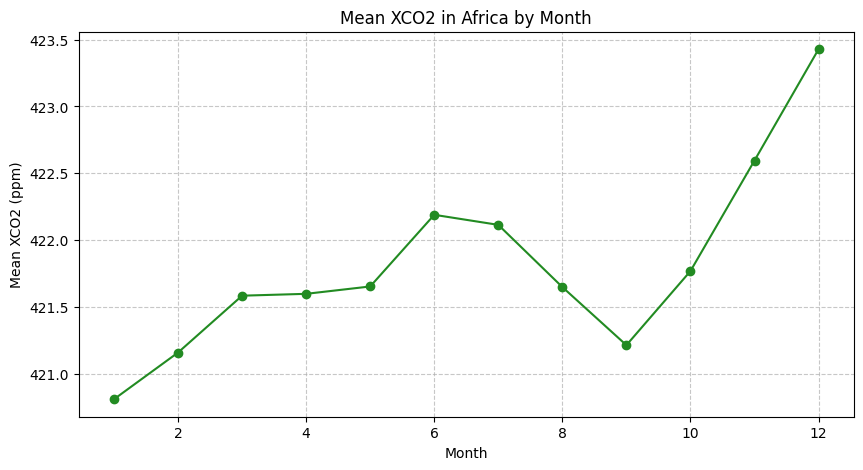

In [6]:
# 4. Monthly timeseries
plot_monthly_timeseries(df_africa)

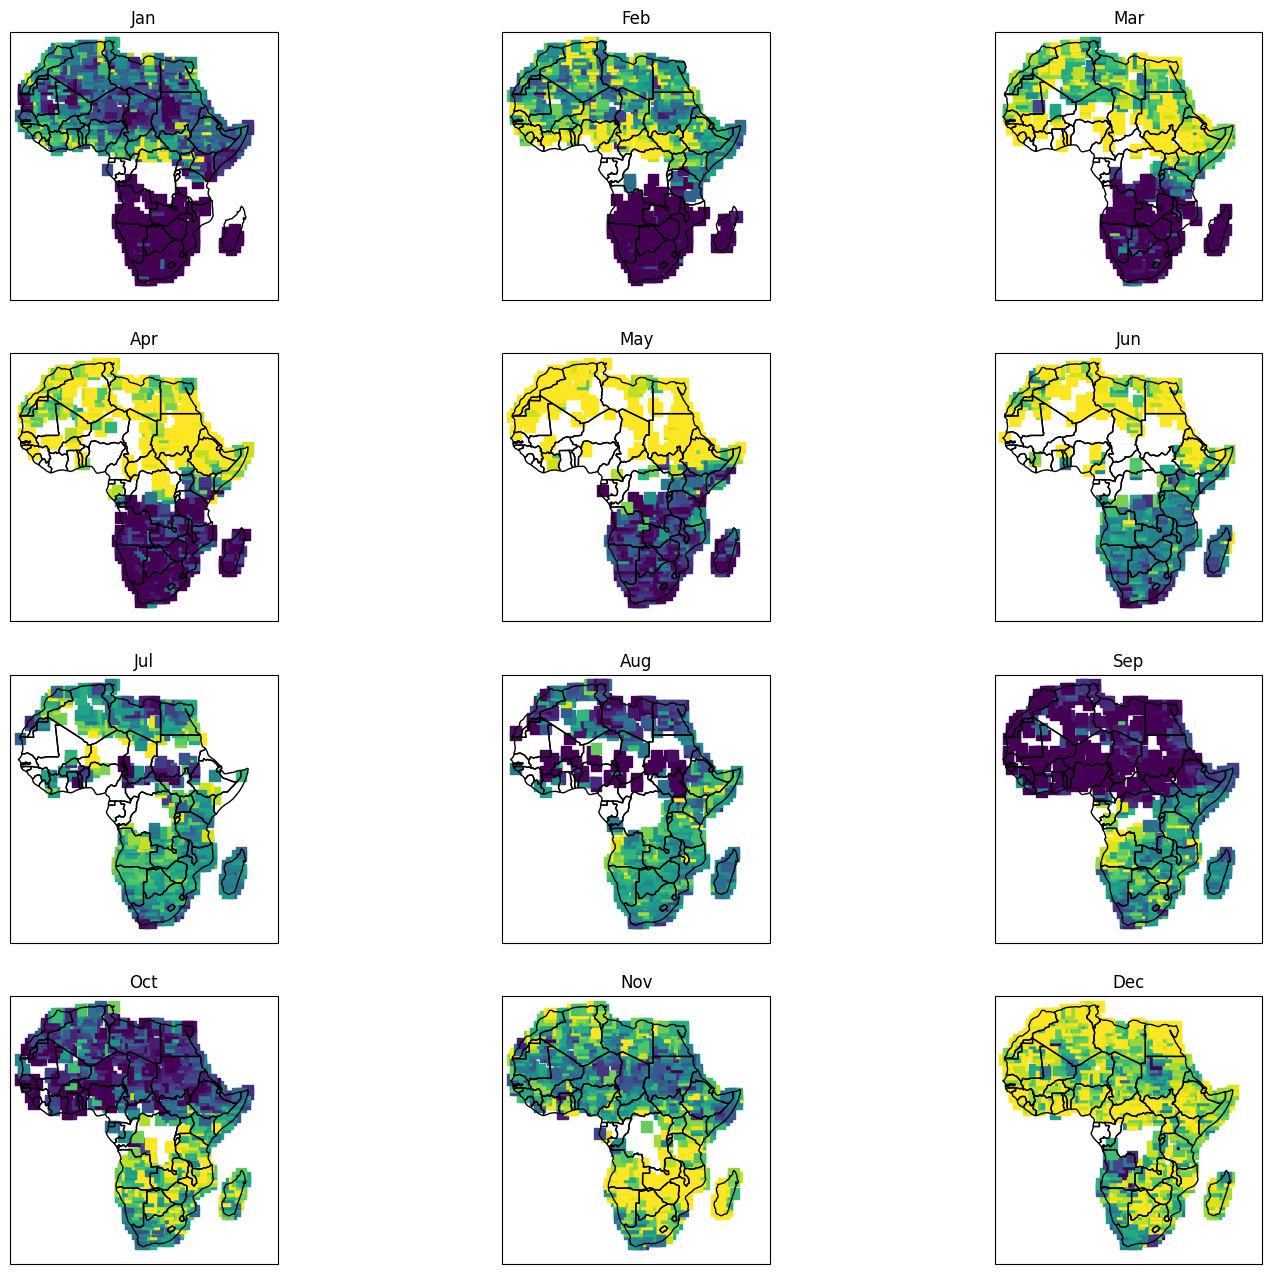

In [14]:
# --- 5. MONTHLY GRID MAPS ---
gdf_points = create_geodataframe_from_grid(df_africa)
gdf_final_points = clip_to_africa(gdf_points, africa_shape)
plot_monthly_grid(gdf_final_points, africa_shape)

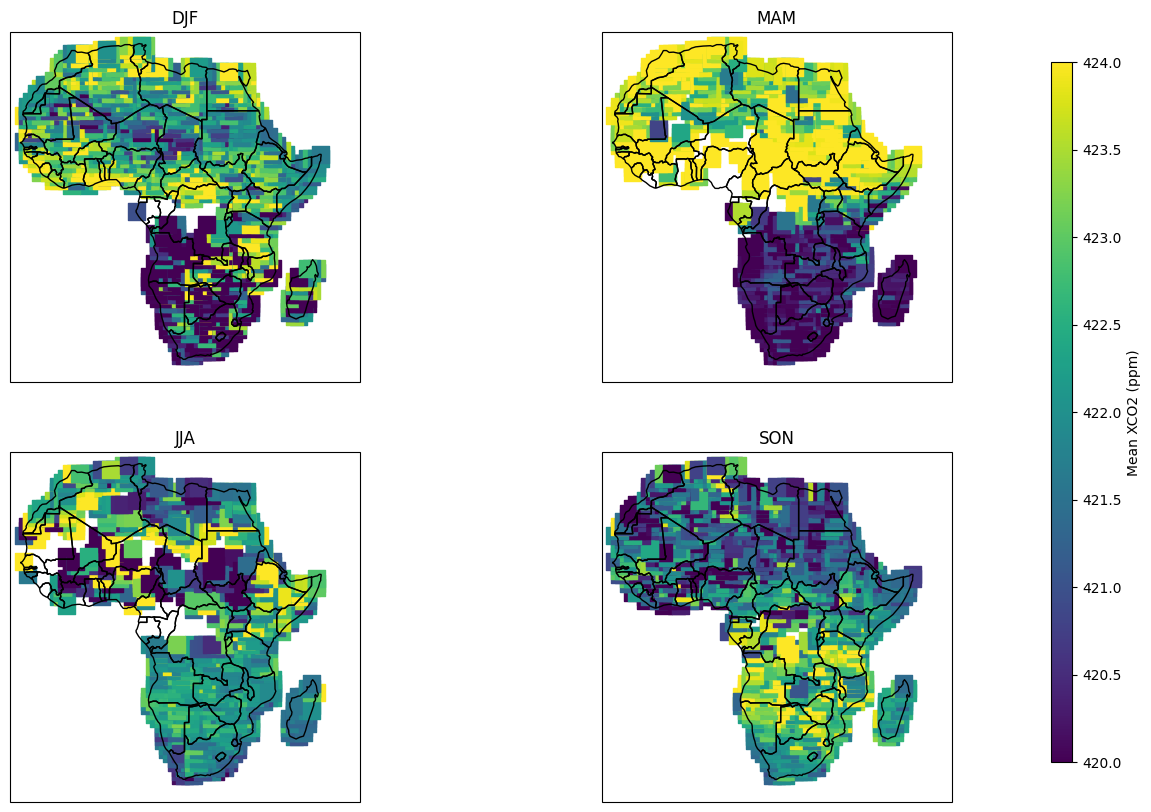

In [15]:
# --- 6. SEASONAL MAPS ---
plot_seasonal_maps(df_africa, africa_shape)

In [26]:
import rasterio
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import numpy as np

In [46]:
tif_path = "data_raster/land_cover_africa_2.tif"
with rasterio.open(tif_path) as src:
    lc_data = src.read(
        1,
        out_shape=(
            1,
            src.height // 10,   # reduce resolution by factor 10
            src.width // 10
        )
    )
    extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
    
palette = [
    "#1d0dff00",'#05450a','#086a10','#54a708','#78d203','#009900',
    '#c6b044','#dcd159','#dade48','#fbff13','#b6ff05',
    '#27ff87','#c24f44','#a5a5a5','#ff6d4c','#69fff8',
    '#f9ffa4']
labels = ['Water','Evergreen Needleleaf Forest','Evergreen Broadleaf Forest','Deciduous Needleleaf Forest',
    'Deciduous Broadleaf Forest','Mixed Forest','Closed Shrublands','Open Shrublands',
    'Woody Savannas','Savannas','Grasslands','Permanent Wetlands','Croplands','Urban',
    'Cropland/Natural Mosaic','Snow/Ice','Barren']

#colormap
cmap = ListedColormap(palette)


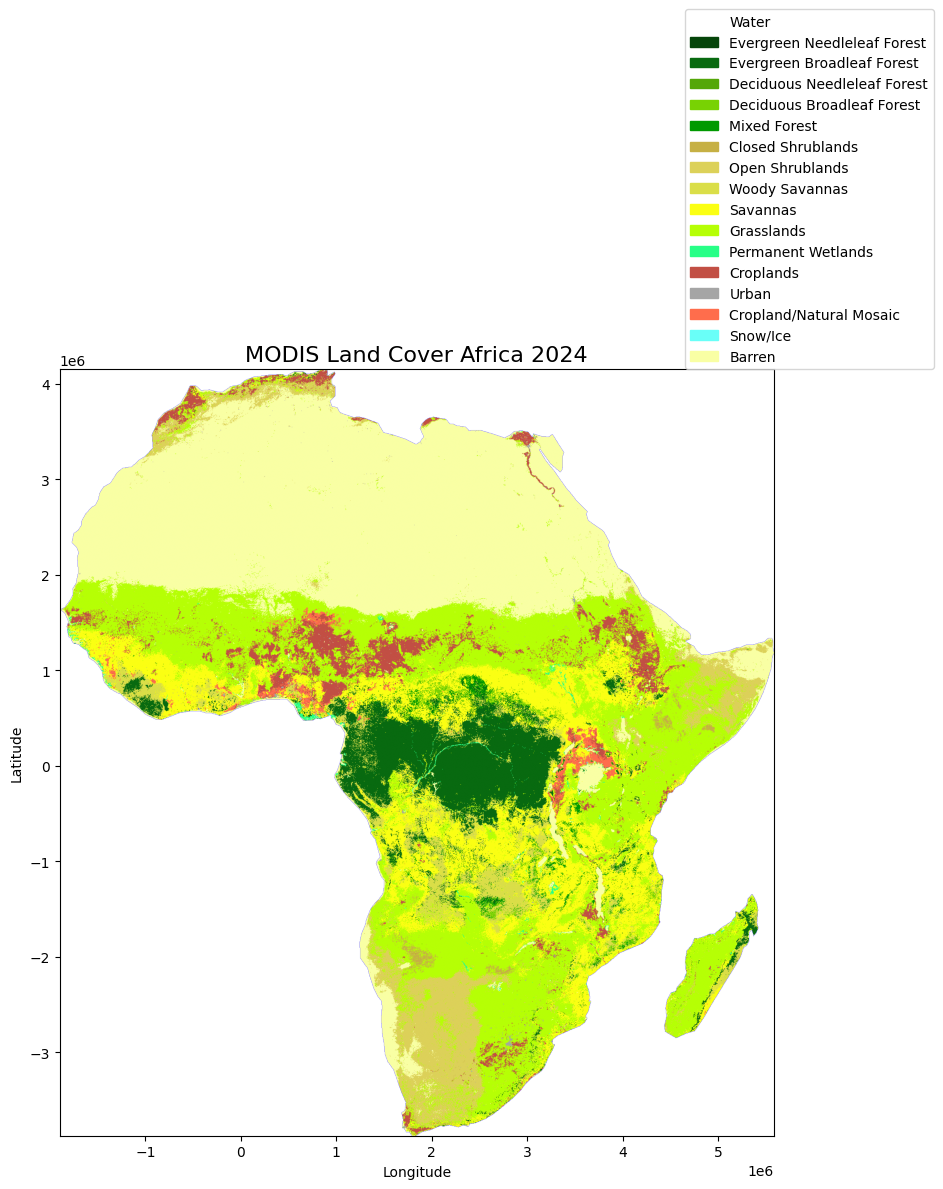

In [ ]:
#plot the raster
plt.figure(figsize=(12,12))
im = plt.imshow(lc_data, cmap=cmap, vmin=0, vmax=17, extent=extent)
plt.title("MODIS Land Cover Africa 2024", fontsize=16)
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# add legend
patches = [Patch(color=palette[i], label=labels[i]) for i in range(len(labels))]
plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=10)

plt.tight_layout()
plt.savefig("./results/land_cover_africa.png", dpi=300, bbox_inches='tight')
plt.show()